In [51]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as otm
import torchvision.models as models
import seaborn as sns
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

In [41]:
print("CUDA có sẵn không:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Tên Card đang dùng:", torch.cuda.get_device_name(0))

CUDA có sẵn không: True
Tên Card đang dùng: NVIDIA GeForce GTX 1650 with Max-Q Design


In [42]:
num_classes = 10

In [43]:
transform = transforms.Compose([
    transforms.Resize((224, 224 )),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

datasettrain = datasets.ImageFolder(
    root="Reduced MNIST Data/Reduced Trainging data",
    transform=transform
)

datatrainloader = DataLoader(
    datasettrain, 
    batch_size=16, 
    shuffle=True,
    num_workers=4,
    pin_memory=True    
)

datasettest = datasets.ImageFolder(
    root="Reduced MNIST Data/Reduced Testing data",
    transform=transform
)

datatestloader = DataLoader(
    datasettest, 
    batch_size=16, 
    num_workers=4,
    pin_memory=True    
)


In [44]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")

In [ ]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = otm.Adam(model.parameters(), lr=0.0001)

In [46]:
for epoch in range(10):
    model.train() 
    
    running_loss = 0.0
    
    for inputs, labels in datatrainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print('Epoch ', epoch + 1, '. Loss: ', round(running_loss/len(datatrainloader), 4))
    
torch.save(model.state_dict(), 'efficient_net.pth')

Epoch  1 . Loss:  0.4337
Epoch  2 . Loss:  0.0826
Epoch  3 . Loss:  0.0522
Epoch  4 . Loss:  0.0381
Epoch  5 . Loss:  0.0289
Epoch  6 . Loss:  0.0195
Epoch  7 . Loss:  0.0183
Epoch  8 . Loss:  0.0123
Epoch  9 . Loss:  0.0161
Epoch  10 . Loss:  0.0095


In [47]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
model.load_state_dict(torch.load('efficient_net.pth'))
model = model.to(device)
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [48]:
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in datatestloader:
        inputs = inputs.to(device)
        labels = labels.to(device)
    
        outputs = model(inputs)
        _, predicted_class = torch.max(outputs, 1)

        all_preds.extend(predicted_class.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [49]:
acc = accuracy_score(all_labels, all_preds)
print('Accuracy: ', round(acc * 100, 4), '%')

print("Báo cáo phân loại chi tiết:")
print(classification_report(all_labels, all_preds, digits=4))

Accuracy:  98.95 %
Báo cáo phân loại chi tiết:
              precision    recall  f1-score   support

           0     1.0000    0.9950    0.9975       200
           1     1.0000    1.0000    1.0000       200
           2     0.9706    0.9900    0.9802       200
           3     0.9950    0.9900    0.9925       200
           4     1.0000    0.9750    0.9873       200
           5     0.9850    0.9850    0.9850       200
           6     0.9950    0.9950    0.9950       200
           7     0.9800    0.9800    0.9800       200
           8     0.9802    0.9900    0.9851       200
           9     0.9900    0.9950    0.9925       200

    accuracy                         0.9895      2000
   macro avg     0.9896    0.9895    0.9895      2000
weighted avg     0.9896    0.9895    0.9895      2000



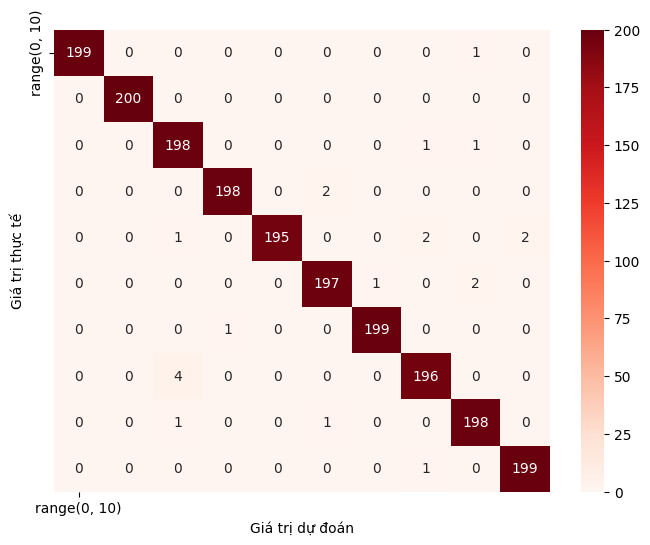

In [52]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=[range(10)], 
            yticklabels=[range(10)])
plt.ylabel('Giá trị thực tế')
plt.xlabel('Giá trị dự đoán')
plt.show()